In [1]:
from pathlib import Path
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

## ETH data

In [ ]:
# eth_raw = yf.Ticker("ETH-USD").history(period="max", interval="1d", auto_adjust=False).reset_index()
# eth_raw["Date"] = pd.to_datetime(pd.to_datetime(eth_raw["Date"], utc=True).dt.date)

# start_date = "2021-01-01"  # first big spike
# today = "2025-11-05"

# eth = eth_raw[(eth_raw["Date"] > start_date) & (eth_raw["Date"] < today)].reset_index().drop(
#     columns=["Dividends", "Stock Splits", "Adj Close", "index"])

# print(eth.Date.min(), eth.Date.max(), len(eth))

# if eth["Date"].diff().value_counts().shape[0] > 1:
#     raise ValueError("Non-uniform dates of prices")

In [ ]:
# eth.to_csv("eth_dev.csv", index=False)

## Deribit - Close

In [7]:
# IN_DIR = Path("deribit_eth_option_trades")
# OUT_FILE = Path("deribit_eth_option_daily_close.parquet")

# def daily_close_from_file(fp: Path) -> pd.DataFrame:
#     df = pd.read_parquet(fp, columns=["instrument_name", "timestamp", "price", "amount"])
#     # sort so "last row" per instrument is the daily close
#     df = df.sort_values(["instrument_name", "timestamp"])

#     # daily aggregates
#     agg = df.groupby("instrument_name", as_index=False).agg(
#         close_ts=("timestamp", "last"),
#         close_price=("price", "last"),
#         daily_volume=("amount", "sum"),
#         n_trades=("price", "size"),
#     )

#     # date from filename: ETH_option_trades_YYYY-MM-DD.parquet
#     date_str = fp.stem.split("_")[-1]
#     agg.insert(0, "date_utc", date_str)
#     return agg

# files = sorted(IN_DIR.glob("ETH_option_trades_*.parquet"))

# all_out = []
# for i, fp in enumerate(files, start=1):
#     out_day = daily_close_from_file(fp)
#     all_out.append(out_day)
#     if i % 50 == 0:
#         print(f"Processed {i}/{len(files)} files...")

# result = pd.concat(all_out, ignore_index=True)
# result.to_parquet(OUT_FILE, index=False)
# print("Saved:", OUT_FILE)


Processed 50/1769 files...
Processed 100/1769 files...
Processed 150/1769 files...
Processed 200/1769 files...
Processed 250/1769 files...
Processed 300/1769 files...
Processed 350/1769 files...
Processed 400/1769 files...
Processed 450/1769 files...
Processed 500/1769 files...
Processed 550/1769 files...
Processed 600/1769 files...
Processed 650/1769 files...
Processed 700/1769 files...
Processed 750/1769 files...
Processed 800/1769 files...
Processed 850/1769 files...
Processed 900/1769 files...
Processed 950/1769 files...
Processed 1000/1769 files...
Processed 1050/1769 files...
Processed 1100/1769 files...
Processed 1150/1769 files...
Processed 1200/1769 files...
Processed 1250/1769 files...
Processed 1300/1769 files...
Processed 1350/1769 files...
Processed 1400/1769 files...
Processed 1450/1769 files...
Processed 1500/1769 files...
Processed 1550/1769 files...
Processed 1600/1769 files...
Processed 1650/1769 files...
Processed 1700/1769 files...
Processed 1750/1769 files...
Saved

## Emprical part

In [2]:
eth = pd.read_csv("eth_dev.csv")
eth["Date"] = pd.to_datetime(eth["Date"])
eth = eth.sort_values("Date").reset_index(drop=True)

eth["Spot_90"] = eth["Close"].shift(-90)
eth["r_90"] = eth["Spot_90"] / eth["Close"] - 1

eth = eth.dropna(subset="r_90", how="any")

In [3]:
close_deribit = pd.read_parquet("deribit_eth_option_daily_close.parquet")
close_deribit["date_utc"] = pd.to_datetime(close_deribit["date_utc"])

# 1) Extract parts
parts = close_deribit["instrument_name"].str.extract(
    r"^(?P<underlying>[A-Z]+)-(?P<exp>\d{1,2}[A-Z]{3}\d{2})-(?P<strike>\d+(?:\.\d+)?)-(?P<cp>[CP])$"
)
close_deribit["underlying"] = parts["underlying"]
close_deribit["option_type"] = parts["cp"].map({"C": "call", "P": "put"})   # or keep "C"/"P"
close_deribit["strike"] = pd.to_numeric(parts["strike"], errors="coerce")

# 2) Expiration to datetime/date
# Deribit uses like 15JAN21 or 9NOV25 (note 1-digit day allowed)
close_deribit["expiration_dt"] = pd.to_datetime(parts["exp"], format="%d%b%y", errors="coerce", utc=True)
close_deribit["expiration_dt"] = (close_deribit["expiration_dt"].dt.tz_convert(None).dt.normalize())

close_deribit["date_utc_dt"] = (pd.to_datetime(close_deribit["date_utc"]).dt.normalize())
close_deribit["TTM"] = (close_deribit["expiration_dt"] - close_deribit["date_utc_dt"]).dt.days

In [4]:
df = close_deribit.merge(
    eth[["Date", "Close", "Spot_90", "r_90"]],
    left_on="date_utc_dt",
    right_on="Date",
    how="inner"
)

df = df.rename(columns={
    "Close": "S_t",
    "strike": "K",
    "close_price": "option_price_eth"
})

In [5]:
df = df[df["option_type"] == "put"].copy()
df["P_t"] = df["option_price_eth"] * df["S_t"]

In [6]:
df = df[
    (df["K"] > 0) &
    (df["S_t"] > 0) &
    (df["P_t"] > 0) &
    df["K"].notna() &
    df["S_t"].notna() &
    df["P_t"].notna() &
    df["TTM"].notna() &
    (df["TTM"] > 0)
].copy()

In [7]:
df["moneyness"] = df["K"] / df["S_t"]
df["premium_ratio"] = df["P_t"] / df["K"]
df["TTM_years"] = df["TTM"] / 365.0

In [8]:
df = df[df["moneyness"] < 1].copy()

df = df.sort_values(["date_utc_dt", "TTM", "K"]).reset_index(drop=True)

### (mult mat, mult fee)

feasibility util

In [9]:
L = 10_000
fees = [0.03, 0.05, 0.08, 0.10]


def add_feasibility_for_fee(base_df: pd.DataFrame, fee: float) -> pd.DataFrame:
    out = base_df.copy()

    out["fee"] = fee
    out["Loan_Amount"] = L
    out["Revenue"] = fee * L

    # Raw K0 bounds
    out["K_0_left"] = out["P_t"] / fee
    out["K_0_right"] = (out["K"] - out["P_t"]) / (1 - fee)

    # Intersection with economically admissible K0 region: 0 < K0 < S_t
    out["K_0_left_adj"] = np.maximum(out["K_0_left"], 0)
    out["K_0_right_adj"] = np.minimum(out["K_0_right"], out["S_t"])

    # Feasible zero-loss quote
    out["is_feasible"] = out["K_0_right_adj"] > out["K_0_left_adj"]

    # LTV bounds
    out["LTV_left"] = out["K_0_left_adj"] / out["S_t"]
    out["LTV_right"] = out["K_0_right_adj"] / out["S_t"]
    out["LTV_width"] = out["LTV_right"] - out["LTV_left"]

    # Market-observable empty-interval diagnostic
    out["premium_ratio_lt_fee"] = out["premium_ratio"] < fee

    return out


feasibility = pd.concat(
    [add_feasibility_for_fee(df, fee) for fee in fees],
    ignore_index=True
)

maturity bucket util

In [10]:
# ------------------------------------------------------------
# Target maturity buckets: 2M, 3M, 4M, 6M
# ------------------------------------------------------------

target_maturity_windows = {
    "2M_60_65D": (60, 65),
    "3M_90_95D": (90, 95),
    "4M_120_125D": (120, 125),
    "6M_180_185D": (180, 185),
}

feasibility["target_maturity_bucket"] = pd.NA

for label, (lower, upper) in target_maturity_windows.items():
    mask = (feasibility["TTM"] >= lower) & (feasibility["TTM"] <= upper)
    feasibility.loc[mask, "target_maturity_bucket"] = label

maturity_order = list(target_maturity_windows.keys())

feasibility["target_maturity_bucket"] = pd.Categorical(
    feasibility["target_maturity_bucket"],
    categories=maturity_order,
    ordered=True
)

# Dataset restricted to target maturities only
feasibility_target_maturities = (
    feasibility
    .dropna(subset=["target_maturity_bucket"])
    .copy()
)

### Quote-stats across buckets

In [11]:
feasible_target_only = feasibility_target_maturities[
    feasibility_target_maturities["is_feasible"]
].copy()

target_maturity_summary = (
    feasibility_target_maturities
    .groupby(["fee", "target_maturity_bucket"], observed=True)
    .agg(
        total_quotes=("instrument_name", "count"),
        feasible_quotes=("is_feasible", "sum"),
        feasibility_rate=("is_feasible", "mean"),
    )
    .reset_index()
)

target_maturity_ltv_summary = (
    feasible_target_only
    .groupby(["fee", "target_maturity_bucket"], observed=True)
    .agg(
        median_LTV_left=("LTV_left", "median"),
        median_LTV_right=("LTV_right", "median"),
        median_LTV_width=("LTV_width", "median"),
    )
    .reset_index()
)

target_maturity_summary = target_maturity_summary.merge(
    target_maturity_ltv_summary,
    on=["fee", "target_maturity_bucket"],
    how="left"
)

target_maturity_summary

,fee,target_maturity_bucket,total_quotes,feasible_quotes,feasibility_rate,median_LTV_left,median_LTV_right,median_LTV_width
0,0.03,2M_60_65D,3246,1545,0.475970,0.233333,0.605395,0.324212
1,0.03,3M_90_95D,1889,699,0.370037,0.233333,0.541189,0.242041
2,0.03,4M_120_125D,1087,352,0.323827,0.200000,0.471652,0.175273
3,0.03,6M_180_185D,705,116,0.164539,0.200000,0.381190,0.157514
4,0.05,2M_60_65D,3246,2079,0.640481,0.210000,0.663191,0.380947
5,0.05,3M_90_95D,1889,1008,0.533616,0.230000,0.602658,0.304884
6,0.05,4M_120_125D,1087,524,0.482061,0.200000,0.512264,0.230551
7,0.05,6M_180_185D,705,220,0.312057,0.260000,0.461432,0.178242
8,0.08,2M_60_65D,3246,2630,0.810228,0.200000,0.729794,0.447507
9,0.08,3M_90_95D,1889,1369,0.724722,0.231250,0.680803,0.361136


### Day-stats across buckets

In [12]:
target_day_level = (
    feasibility_target_maturities
    .groupby(["fee", "target_maturity_bucket", "date_utc_dt"], observed=True)
    .agg(
        day_has_feasible_quote=("is_feasible", "max"),
        feasible_quotes_per_day=("is_feasible", "sum"),
        total_quotes_per_day=("is_feasible", "count"),
    )
    .reset_index()
)

target_day_level_summary = (
    target_day_level
    .groupby(["fee", "target_maturity_bucket"], observed=True)
    .agg(
        total_days=("date_utc_dt", "count"),
        feasible_days=("day_has_feasible_quote", "sum"),
        day_feasibility_rate=("day_has_feasible_quote", "mean"),
        median_feasible_quotes_per_day=("feasible_quotes_per_day", "median"),
        median_total_quotes_per_day=("total_quotes_per_day", "median"),
    )
    .reset_index()
)

target_day_level_summary

,fee,target_maturity_bucket,total_days,feasible_days,day_feasibility_rate,median_feasible_quotes_per_day,median_total_quotes_per_day
0,0.03,2M_60_65D,336,308,0.916667,4.0,9.0
1,0.03,3M_90_95D,232,184,0.793103,2.0,8.0
2,0.03,4M_120_125D,108,93,0.861111,3.0,10.0
3,0.03,6M_180_185D,107,62,0.579439,1.0,6.0
4,0.05,2M_60_65D,336,333,0.991071,6.0,9.0
5,0.05,3M_90_95D,232,208,0.896552,4.0,8.0
6,0.05,4M_120_125D,108,100,0.925926,5.0,10.0
7,0.05,6M_180_185D,107,80,0.747664,1.0,6.0
8,0.08,2M_60_65D,336,335,0.997024,8.0,9.0
9,0.08,3M_90_95D,232,221,0.952586,5.0,8.0


fee sensitivity util

In [13]:
# Main empirical sample: only target maturities
analysis_df = feasibility_target_maturities.copy()

# -----------------------------
# Quote-level success rate
# -----------------------------
quote_fee_summary = (
    analysis_df
    .groupby("fee")
    .agg(
        total_quotes=("instrument_name", "count"),
        feasible_quotes=("is_feasible", "sum"),
        quote_success_rate=("is_feasible", "mean"),
    )
    .reset_index()
)

# -----------------------------
# Day-level success rate
# A day is feasible if at least one quote is feasible
# -----------------------------
day_fee_panel = (
    analysis_df
    .groupby(["fee", "date_utc_dt"])
    .agg(
        day_has_feasible_quote=("is_feasible", "max"),
        feasible_quotes_per_day=("is_feasible", "sum"),
        total_quotes_per_day=("is_feasible", "count"),
    )
    .reset_index()
)

day_fee_summary = (
    day_fee_panel
    .groupby("fee")
    .agg(
        total_days=("date_utc_dt", "count"),
        feasible_days=("day_has_feasible_quote", "sum"),
        day_success_rate=("day_has_feasible_quote", "mean"),
        median_feasible_quotes_per_day=("feasible_quotes_per_day", "median"),
    )
    .reset_index()
)

# -----------------------------
# Combined fee sensitivity table
# -----------------------------
fee_sensitivity_summary = quote_fee_summary.merge(
    day_fee_summary,
    on="fee",
    how="left"
)

### Quote-day fee sensitivity (addtion to the summary)

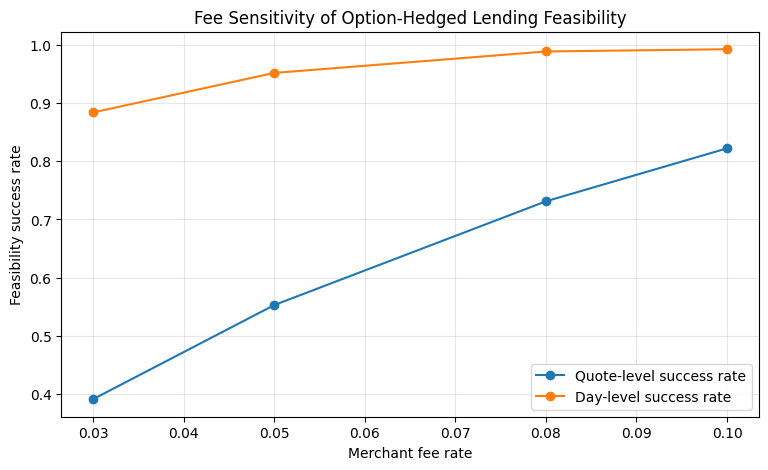

In [14]:
plt.figure(figsize=(9, 5))

plt.plot(
    fee_sensitivity_summary["fee"],
    fee_sensitivity_summary["quote_success_rate"],
    marker="o",
    label="Quote-level success rate"
)

plt.plot(
    fee_sensitivity_summary["fee"],
    fee_sensitivity_summary["day_success_rate"],
    marker="o",
    label="Day-level success rate"
)

plt.xlabel("Merchant fee rate")
plt.ylabel("Feasibility success rate")
plt.title("Fee Sensitivity of Option-Hedged Lending Feasibility")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("image.png", dpi=300, bbox_inches="tight")

plt.show()

LTV util

In [15]:
def safe_max_feasible_ltv_right(x):
    feasible = x[x["is_feasible"]]
    if feasible.empty:
        return np.nan
    return feasible["LTV_right"].max()


def safe_median_feasible_ltv_width(x):
    feasible = x[x["is_feasible"]]
    if feasible.empty:
        return np.nan
    return feasible["LTV_width"].median()


time_series_summary = (
    analysis_df
    .groupby(["date_utc_dt", "fee"])
    .apply(
        lambda x: pd.Series({
            "total_quotes": len(x),
            "feasible_quotes": x["is_feasible"].sum(),
            "day_has_feasible_quote": x["is_feasible"].max(),
            "best_feasible_LTV_right": safe_max_feasible_ltv_right(x),
            "median_feasible_LTV_width": safe_median_feasible_ltv_width(x),
        })
    )
    .reset_index()
)

time_series_summary["feasibility_rate"] = (
    time_series_summary["feasible_quotes"] / time_series_summary["total_quotes"]
)

/var/folders/kn/bjw4dyk92c972dmk_bv54q9r0000gn/T/ipykernel_5121/1037440817.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


ts util

In [16]:
# ------------------------------------------------------------
# Re-format best feasible LTV upper bound over time
# Monthly median + interquartile range
# ------------------------------------------------------------

ts = time_series_summary.copy()
ts["date_utc_dt"] = pd.to_datetime(ts["date_utc_dt"])

# Monthly grouping
ts["month"] = ts["date_utc_dt"].dt.to_period("M").dt.to_timestamp()

monthly_ltv_summary = (
    ts
    .groupby(["fee", "month"])
    .agg(
        total_days=("date_utc_dt", "count"),
        feasible_days=("day_has_feasible_quote", "sum"),
        day_success_rate=("day_has_feasible_quote", "mean"),
        median_best_LTV_right=("best_feasible_LTV_right", "median"),
        q25_best_LTV_right=("best_feasible_LTV_right", lambda x: x.quantile(0.25)),
        q75_best_LTV_right=("best_feasible_LTV_right", lambda x: x.quantile(0.75)),
        mean_best_LTV_right=("best_feasible_LTV_right", "mean"),
    )
    .reset_index()
)

### Best feasible LTV upper bound over time

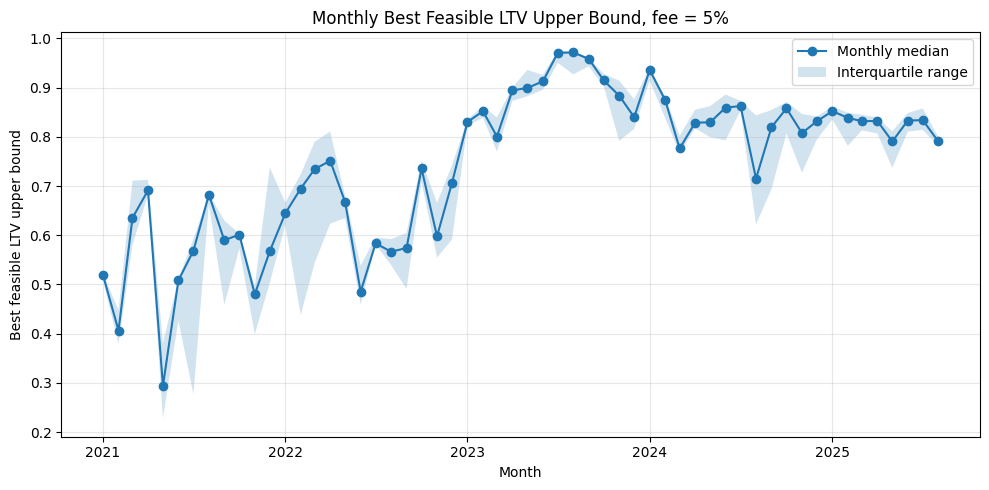

In [17]:
# ------------------------------------------------------------
# Paper-friendly plot: monthly best feasible LTV, baseline fee
# ------------------------------------------------------------

baseline_fee = 0.05

plot_df = monthly_ltv_summary[
    monthly_ltv_summary["fee"] == baseline_fee
].copy()

plt.figure(figsize=(10, 5))

plt.plot(
    plot_df["month"],
    plot_df["median_best_LTV_right"],
    marker="o",
    label="Monthly median"
)

plt.fill_between(
    plot_df["month"],
    plot_df["q25_best_LTV_right"],
    plot_df["q75_best_LTV_right"],
    alpha=0.2,
    label="Interquartile range"
)

plt.xlabel("Month")
plt.ylabel("Best feasible LTV upper bound")
plt.title(f"Monthly Best Feasible LTV Upper Bound, fee = {baseline_fee:.0%}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("image 1.png", dpi=300, bbox_inches="tight")

plt.show()

Best available structure construction util

In [18]:
# ------------------------------------------------------------
# Best available structure per day
# Rule: maximize Profit_max / L
# ------------------------------------------------------------

best_structure_df = analysis_df.copy()

# Choose K0 inside the corrected global feasible interval.
# Since Profit_max / L = fee - P_t / K0 is increasing in K0,
# the best K0 for a given quote is still the adjusted right boundary.
best_structure_df["K_0_chosen"] = best_structure_df["K_0_right_adj"]
best_structure_df["LTV_chosen"] = best_structure_df["K_0_chosen"] / best_structure_df["S_t"]

# Profit_max / L
best_structure_df["Profit_max_over_L"] = (
    best_structure_df["fee"] - best_structure_df["P_t"] / best_structure_df["K_0_chosen"]
)

# Dollar profit, using your assumed loan amount L
best_structure_df["Profit_max"] = L * best_structure_df["Profit_max_over_L"]

# Keep feasible quotes only
best_structure_feasible = best_structure_df[
    best_structure_df["is_feasible"]
].copy()

# For each date and fee, select the quote with the highest Profit_max / L
idx_best = (
    best_structure_feasible
    .groupby(["date_utc_dt", "fee"])["Profit_max_over_L"]
    .idxmax()
)

best_structure_per_day = (
    best_structure_feasible
    .loc[idx_best]
    .sort_values(["date_utc_dt", "fee"])
    .reset_index(drop=True)
)

### Best available structure summary table

In [19]:
best_structure_summary = (
    best_structure_per_day
    .groupby("fee")
    .agg(
        days_with_best_structure=("date_utc_dt", "nunique"),
        median_Profit_max_over_L=("Profit_max_over_L", "median"),
        mean_Profit_max_over_L=("Profit_max_over_L", "mean"),
        median_LTV_chosen=("LTV_chosen", "median"),
        median_LTV_width=("LTV_width", "median"),
        median_moneyness=("moneyness", "median"),
        median_TTM=("TTM", "median"),
        median_premium_ratio=("premium_ratio", "median"),
    )
    .reset_index()
)

best_structure_summary

,fee,days_with_best_structure,median_Profit_max_over_L,mean_Profit_max_over_L,median_LTV_chosen,median_LTV_width,median_moneyness,median_TTM,median_premium_ratio
0,0.03,456,0.024739,0.021566,0.374670,0.254761,0.364699,65.0,0.005394
1,0.05,491,0.044273,0.039636,0.394304,0.293057,0.378888,65.0,0.005992
2,0.08,510,0.074048,0.068099,0.415660,0.333278,0.386193,65.0,0.006428
3,0.10,512,0.094122,0.088057,0.428131,0.363265,0.388130,65.0,0.006489


### Best available profit plot

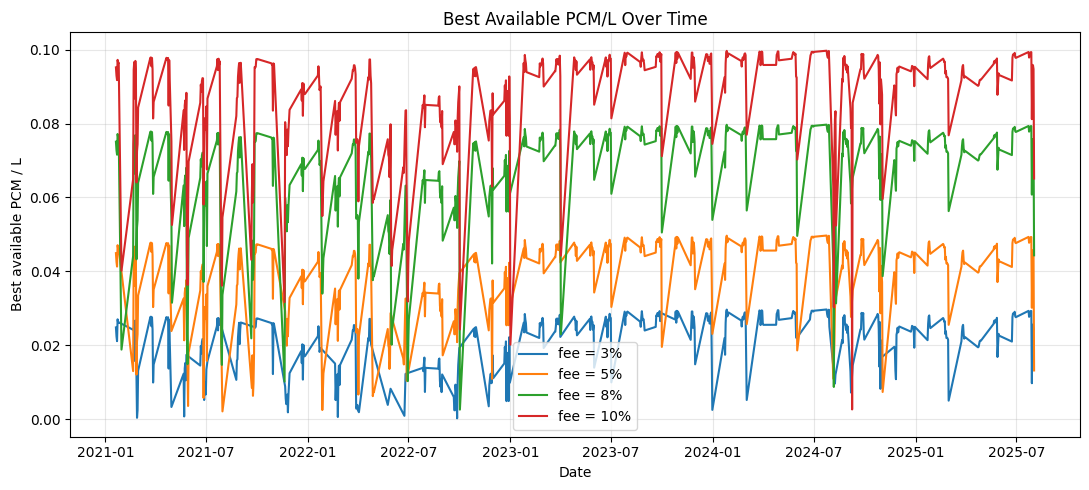

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 5))

for fee in sorted(best_structure_per_day["fee"].unique()):
    temp = best_structure_per_day[best_structure_per_day["fee"] == fee]
    plt.plot(
        temp["date_utc_dt"],
        temp["Profit_max_over_L"],
        label=f"fee = {fee:.0%}"
    )

plt.xlabel("Date")
plt.ylabel("Best available PCM / L")
plt.title("Best Available PCM/L Over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("image 2.png", dpi=300, bbox_inches="tight")

plt.show()

beta util

In [21]:
# ------------------------------------------------------------
# Bounded-loss feasibility function
# ------------------------------------------------------------

def add_feasibility_for_fee_beta(base_df: pd.DataFrame, fee: float, beta: float) -> pd.DataFrame:
    out = base_df.copy()

    out["fee"] = fee
    out["beta"] = beta
    out["Loan_Amount"] = L
    out["Revenue"] = fee * L
    out["Loss_Budget"] = beta * L

    denom = 1 - fee - beta
    out["valid_fee_beta"] = denom > 0

    # Left boundary is unchanged
    out["K_0_left"] = out["P_t"] / fee

    # Right boundary changes under bounded-loss feasibility
    if denom > 0:
        out["K_0_right"] = (out["K"] - out["P_t"]) / denom
    else:
        out["K_0_right"] = np.nan

    # Intersect with economically admissible region: 0 < K0 < S_t
    out["K_0_left_adj"] = np.maximum(out["K_0_left"], 0)
    out["K_0_right_adj"] = np.minimum(out["K_0_right"], out["S_t"])

    out["is_feasible"] = (
        out["valid_fee_beta"] &
        (out["K_0_right_adj"] > out["K_0_left_adj"])
    )

    out["LTV_left"] = out["K_0_left_adj"] / out["S_t"]
    out["LTV_right"] = out["K_0_right_adj"] / out["S_t"]
    out["LTV_width"] = out["LTV_right"] - out["LTV_left"]

    return out

beta grid util

In [22]:
# ------------------------------------------------------------
# Fee and beta grids
# ------------------------------------------------------------

fees = [0.03, 0.05, 0.08, 0.10]
betas = [0.00, 0.01, 0.03, 0.05]

feasibility_beta = pd.concat(
    [
        add_feasibility_for_fee_beta(df, fee=fee, beta=beta)
        for fee in fees
        for beta in betas
    ],
    ignore_index=True
)

beta feasibility utils

In [23]:
# ------------------------------------------------------------
# Target maturity buckets for bounded-loss panel
# ------------------------------------------------------------

target_maturity_windows = {
    "2M_60_65D": (60, 65),
    "3M_90_95D": (90, 95),
    "4M_120_125D": (120, 125),
    "6M_180_185D": (180, 185),
}

feasibility_beta["target_maturity_bucket"] = pd.NA

for label, (lower, upper) in target_maturity_windows.items():
    mask = (
        (feasibility_beta["TTM"] >= lower) &
        (feasibility_beta["TTM"] <= upper)
    )
    feasibility_beta.loc[mask, "target_maturity_bucket"] = label

maturity_order = list(target_maturity_windows.keys())

feasibility_beta["target_maturity_bucket"] = pd.Categorical(
    feasibility_beta["target_maturity_bucket"],
    categories=maturity_order,
    ordered=True
)

feasibility_beta_target_maturities = (
    feasibility_beta
    .dropna(subset=["target_maturity_bucket"])
    .copy()
)

beta-days analysis

In [24]:
beta_day_panel = (
    feasibility_beta_target_maturities
    .groupby(["fee", "beta", "date_utc_dt"], observed=True)
    .agg(
        day_has_feasible_quote=("is_feasible", "max"),
        feasible_quotes_per_day=("is_feasible", "sum"),
        total_quotes_per_day=("is_feasible", "count"),
    )
    .reset_index()
)

beta_day_summary = (
    beta_day_panel
    .groupby(["fee", "beta"], observed=True)
    .agg(
        total_days=("date_utc_dt", "count"),
        feasible_days=("day_has_feasible_quote", "sum"),
        day_success_rate=("day_has_feasible_quote", "mean"),
        median_feasible_quotes_per_day=("feasible_quotes_per_day", "median"),
    )
    .reset_index()
)

### Bounded-Loss Feasilibility, Days

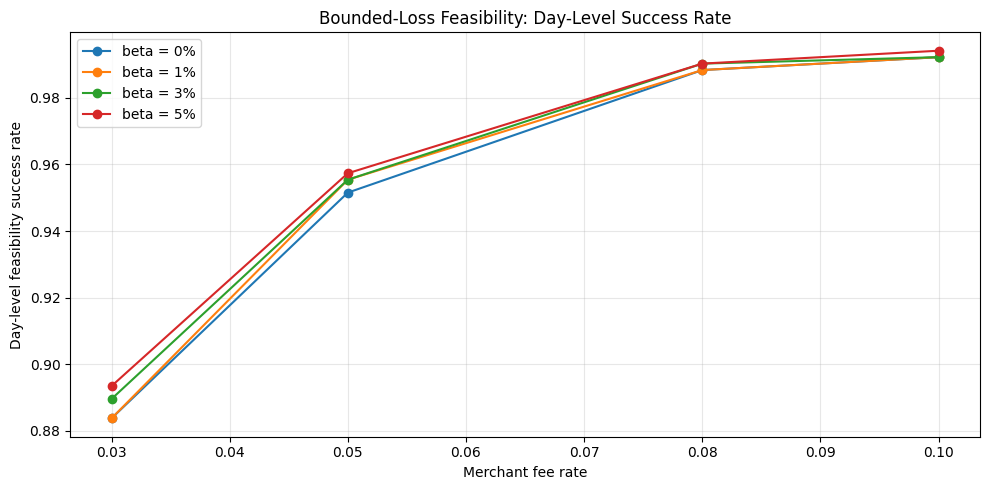

In [25]:
plt.figure(figsize=(10, 5))

for beta in sorted(beta_day_summary["beta"].unique()):
    temp = beta_day_summary[beta_day_summary["beta"] == beta]
    plt.plot(
        temp["fee"],
        temp["day_success_rate"],
        marker="o",
        label=f"beta = {beta:.0%}"
    )

plt.xlabel("Merchant fee rate")
plt.ylabel("Day-level feasibility success rate")
plt.title("Bounded-Loss Feasibility: Day-Level Success Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("image 3.png", dpi=300, bbox_inches="tight")

plt.show()